In [17]:
from utils import create_new_dataset, create_surv_data
from lifelines import KaplanMeierFitter, WeibullAFTFitter
from sksurv.metrics import concordance_index_ipcw
from sksurv.util import Surv
from sklearn.model_selection import train_test_split
import seaborn as sns

# 1 monat krankmeldung

# zensierrate rumspielen ... %  an teil der zensierung  0.1 / 0.25 / 0.5
# Fallzahll rumspielen
# shape parameter 

# zeitabhängige kovariate, da weibull modell(zur schätzun )  es schwierieger hat

# logistic regression theroetische wahre varainz möglich 
# vergleichen mit empirischer standardabweichung 

# streuung von blanche schätzung varanzschätzer mit streuung von jackknife schätzer vergleichen

# 05-18.08 frau jahn urlaub 
# registerdatrem 5600 = n

# logistische regression / cox / xgb / random forest 

# nachlesen random forest standardfehler schätzung 

# registerdaten 85 % tensierung 

### Datensatz erstellen

Data shape: (1000, 7)
34.0 % of the data has an event


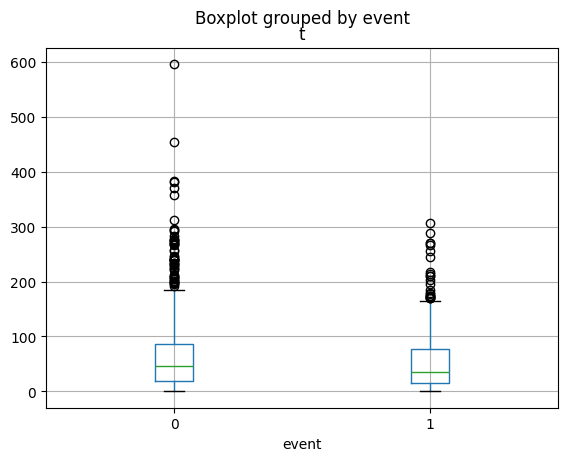

survived
999    0.587
0      0.309
1      0.104
Name: proportion, dtype: float64

In [18]:
import numpy as np
import pandas as pd
from lifelines import WeibullAFTFitter
import matplotlib.pyplot as plt

n = 1000
seed = 42

df = create_surv_data(shape_weibull=1,   # constant hazard
                        scale_weibull_base=10000, 
                        rate_censoring=0.01,  
                        b_bloodp=-0.405, 
                        b_diab=-0.4, 
                        b_age=-0.05, 
                        b_bmi=-0.01, 
                        b_kreat=-0.2,
                        n=n, 
                        seed=42)

df.boxplot(column='t', by='event', grid=True)
plt.show()

# cutpoint for the time t
t = 150
df = create_new_dataset(df,t)
df['survived'].value_counts(normalize=True)

In [19]:
df.head(10)

,bmi,blood_pressure,kreatinkinase,diabetes,age,t,event,survived
0,27.483571,0,108.939308,0,69.203675,196.256897,0,1
1,24.308678,0,69.954400,0,37.771050,123.713342,0,999
2,28.238443,0,204.215235,0,50.712537,65.821494,0,999
3,32.615149,1,567.051680,0,37.064924,73.464362,0,999
4,23.829233,0,30.000000,0,43.043051,369.870902,0,1
5,23.829315,1,166.505123,1,40.818730,271.106976,1,1
6,32.896064,0,126.452558,0,62.395840,17.188231,1,0
7,28.837174,0,290.423463,0,46.037703,124.512726,1,0
8,22.652628,1,183.680278,1,60.683793,21.970281,0,999
9,27.712800,1,69.967487,0,56.041209,11.788910,1,0


### Tranformation der Kovariaten

In [20]:
#df['bmi'] = (df['bmi']-25)**2
#df['kreatinkinase'] = np.log(df['kreatinkinase'])

### Train und Testsplit

In [21]:
X = df[['bmi', 'blood_pressure', 'kreatinkinase', 'diabetes', 'age']]
y = Surv.from_arrays(event=df['event'], time=df['t'])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=seed)

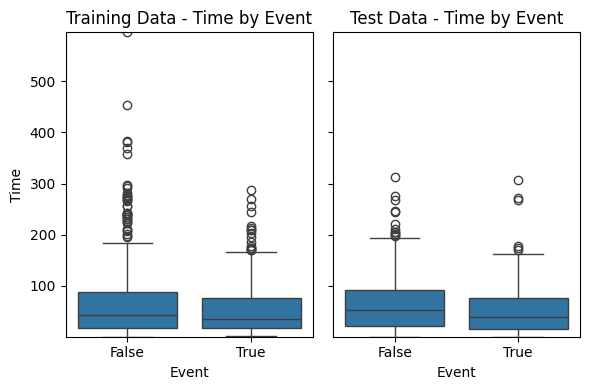

Relative Häufigkeiten der Events - Trainingsdaten:
event
False    0.66
True     0.34
Name: proportion, dtype: float64

Relative Häufigkeiten der Events - Testdaten:
event
False    0.66
True     0.34
Name: proportion, dtype: float64


In [29]:
y_train_df = pd.DataFrame({'event': [event for event, time in y_train], 'time': [time for event, time in y_train]})
y_test_df = pd.DataFrame({'event': [event for event, time in y_test], 'time': [time for event, time in y_test]})

fig, axes = plt.subplots(1, 2, figsize=(6, 4), sharey=True)
sns.boxplot(ax=axes[0], x='event', y='time', data=y_train_df)
axes[0].set_title('Training Data - Time by Event')
axes[0].set_xlabel('Event')
axes[0].set_ylabel('Time')
sns.boxplot(ax=axes[1], x='event', y='time', data=y_test_df)
axes[1].set_title('Test Data - Time by Event')
axes[1].set_xlabel('Event')
axes[1].set_ylabel('Time')
y_min = min(y_train_df['time'].min(), y_test_df['time'].min())
y_max = max(y_train_df['time'].max(), y_test_df['time'].max())
axes[0].set_ylim(y_min, y_max)
axes[1].set_ylim(y_min, y_max)
plt.tight_layout()
plt.show()

train_event_counts = y_train_df['event'].value_counts(normalize=True)
test_event_counts = y_test_df['event'].value_counts(normalize=True)
print("Relative Häufigkeiten der Events - Trainingsdaten:")
print(train_event_counts)
print("\nRelative Häufigkeiten der Events - Testdaten:")
print(test_event_counts)

### Weibull Modell fitten

In [12]:
# Kaplan-Meier-Schätzung für Zensierverteilung
kmf = KaplanMeierFitter()
kmf.fit(data['t'], event_observed=1-data['event'])
censoring_prob = 1 - kmf.survival_function_at_times([t]).values[0]
censoring_prob_after_t = 1-censoring_prob
print(censoring_prob_after_t)

# IPC-Gewichte 



data_bi['ipc_weight'] = 1 / censoring_prob_after_t
#data_bi.loc[data['event'] == 0, 'ipc_weight'] = 


# cutpoint for the time t
t = 150
data_bi = create_new_dataset(data,t)
data_bi['survived'].value_counts(normalize=True)

0.22106037896760278


,bmi,blood_pressure,kreatinkinase,diabetes,age,t,event,ipc_weight
0,27.483571,0,108.939308,0,69.203675,150,0,0.000000
1,24.308678,0,69.954400,0,37.771050,150,0,0.000000
2,28.238443,0,204.215235,0,50.712537,150,0,0.000000
3,32.615149,1,567.051680,0,37.064924,150,0,0.000000
4,23.829233,0,30.000000,0,43.043051,150,0,0.000000
...,...,...,...,...,...,...,...,...
995,23.594499,0,77.496655,0,68.205439,150,0,0.000000
996,33.988433,0,44.558331,0,44.336054,150,0,0.000000
997,28.204214,0,52.350191,0,58.316168,150,1,0.004524
998,22.144105,0,91.176490,0,52.094701,150,0,0.000000


In [14]:
data_bi['ipc_weight'].sum()

1.5380413332677234